Text Representation using Bag of Words

In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv('spam (2).csv')
# Load the dataset and inspect the first few rows.
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.Category.value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [12]:
df['Spam'] = df.Category.apply(lambda x: 1 if x == 'spam' else 0)
df.head()

,Category,Message,Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
df.shape

(5572, 3)

Train/Test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.Message, df.Spam, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4457,), (1115,), (4457,), (1115,))

In [15]:
type(X_train)

pandas.Series

In [16]:
X_train[:4]

2090    No i'm not. I can't give you everything you wa...
1566    The  &lt;#&gt; g that i saw a few days ago, th...
3908               No that just means you have a fat head
4157    Yo, call me when you get the chance, a friend ...
Name: Message, dtype: str

In [17]:
print(type(y_train))
print(y_train[:4])
print(type(y_train.values))

<class 'pandas.Series'>
2090    0
1566    0
3908    0
4157    0
Name: Spam, dtype: int64
<class 'numpy.ndarray'>


Create bag of words representation using CountVectorizer

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()

X_train_cv = v.fit_transform(X_train)
print(X_train_cv.shape)

(4457, 7789)


In [19]:
X_train_cv.toarray()[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 7789))

In [20]:
v.get_feature_names_out()[1021]

'anyways'

In [21]:
v.vocabulary_

{'no': 4800,
 'not': 4835,
 'can': 1644,
 'give': 3159,
 'you': 7752,
 'everything': 2695,
 'want': 7421,
 'and': 977,
 'need': 4732,
 'actually': 828,
 'could': 2048,
 'do': 2394,
 'better': 1348,
 'for': 2953,
 'yourself': 7760,
 'on': 4943,
 'yor': 7750,
 'own': 5047,
 've': 7299,
 'got': 3213,
 'more': 4586,
 'money': 4572,
 'than': 6839,
 'get': 3134,
 'work': 7641,
 'man': 4341,
 'pay': 5132,
 'the': 6852,
 'rent': 5732,
 'even': 2683,
 'fill': 2859,
 'my': 4667,
 'fucking': 3046,
 'gas': 3096,
 'tank': 6742,
 'yes': 7735,
 'stressed': 6547,
 'depressed': 2273,
 'didn': 2321,
 'call': 1620,
 'home': 3482,
 'thanksgiving': 6843,
 'cuz': 2152,
 'll': 4167,
 'have': 3367,
 'to': 6970,
 'tell': 6789,
 'them': 6861,
 'up': 7221,
 'nothing': 4840,
 'lt': 4257,
 'gt': 3270,
 'that': 6849,
 'saw': 5959,
 'few': 2838,
 'days': 2198,
 'ago': 886,
 'guy': 3290,
 'wants': 7425,
 'sell': 6032,
 'wifi': 7559,
 'only': 4954,
 'with': 7594,
 '3g': 475,
 'why': 7551,
 'blanked': 1399,
 'him': 344

In [23]:
X_train_np = X_train_cv.toarray()
X_train_np[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(7789,))

In [24]:
np.where(X_train_np[0] == 1)

(array([ 828, 1348, 1620, 2048, 2152, 2273, 2321, 2695, 2859, 3046, 3096,
        3159, 3213, 3367, 3482, 4167, 4341, 4572, 4586, 4667, 4732, 4800,
        4835, 4840, 4943, 5047, 5132, 5732, 6547, 6742, 6789, 6839, 6843,
        6852, 6861, 7221, 7299, 7421, 7641, 7735, 7750, 7760]),)

In [26]:
print(X_train.iloc[0][:1000])

No i'm not. I can't give you everything you want and need. You actually could do better for yourself on yor own--you've got more money than i do. I can't get work, i can't get a man, i can't pay the rent, i can't even fill my fucking gas tank. yes, i'm stressed and depressed. I didn't even call home for thanksgiving cuz i'll have to tell them i,m up to nothing.


In [27]:
# Train the naive bayes model
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_cv, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Evaluate model performance

In [28]:
X_test_cv = v.transform(X_test)
model.score(X_test_cv, y_test)

0.9838565022421525

In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_cv)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [30]:
emails = ['Hey mohan, can we get together to watch footbal game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

emails_cv = v.transform(emails)
model.predict(emails_cv)

array([0, 1])

Train the model using sklearn pipeline and reduce number of lines of code

In [31]:
from sklearn.pipeline import Pipeline

clfr = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('model', MultinomialNB())
])
clfr.fit(X_train, y_train)
clfr.score(X_test, y_test)

0.9838565022421525

In [32]:
# Generate predictions on the test set so we can evaluate the pipeline output.
y_pred = clfr.predict(X_test)
# Print precision, recall, F1-score, and accuracy for each class.
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



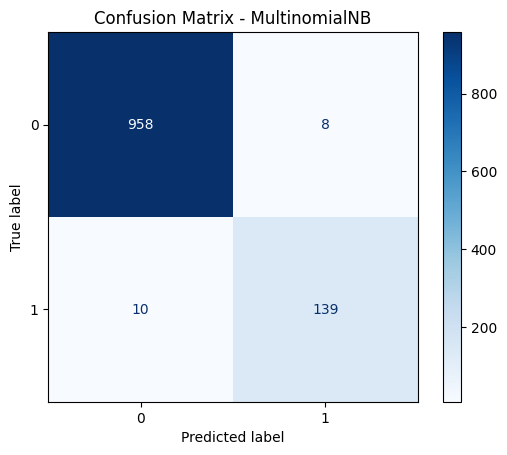

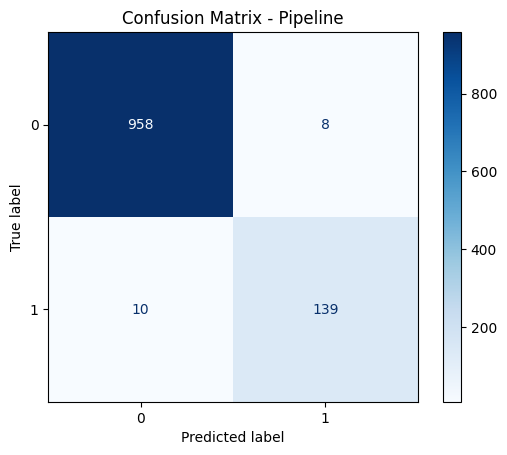

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Build a small helper so the same confusion-matrix logic can be reused for multiple models.
def plot_confusion_matrix(estimator, features, labels, title):
    # Predict the labels, compute the matrix, and display it as a heatmap.
    predictions = estimator.predict(features)
    matrix = confusion_matrix(labels, predictions)
    display = ConfusionMatrixDisplay(confusion_matrix=matrix)
    display.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()


# Show the confusion matrix for the bag-of-words MultinomialNB model.
plot_confusion_matrix(model, X_test_cv, y_test, "Confusion Matrix - MultinomialNB")

# If the pipeline model exists, show its confusion matrix too for comparison
if "clfr" in globals():
    plot_confusion_matrix(clfr, X_test, y_test, "Confusion Matrix - Pipeline")

## Evaluation Report

- The pipeline reaches **98% accuracy** on the test set.
- Class **0** is classified very well, with **964** correct predictions and only **5** mistakes.
- Class **1** is also strong, with **131** correct predictions and **15** misses.
- The classification report shows balanced overall performance: precision is **0.98** for class 0 and **0.96** for class 1, while recall is **0.99** for class 0 and **0.90** for class 1.
- Both confusion matrices are identical, which means the standalone MultinomialNB model and the pipeline are producing the same predictions on the test data.

### Conclusion
The bag-of-words approach with Multinomial Naive Bayes performs well overall. The model is especially strong at identifying class 0, and it misses a few more class 1 examples, so improving recall for class 1 would be the main next step if higher sensitivity is needed.